In [1]:
# Load and unzip data 


#!wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip -P data
#!cd data && unzip PennFudanPed.zip
!export CUDA_VISIBLE_DEVICES=0

import torch
torch.cuda.empty_cache()

tensor([0, 1, 2, 3, 4], dtype=torch.uint8)


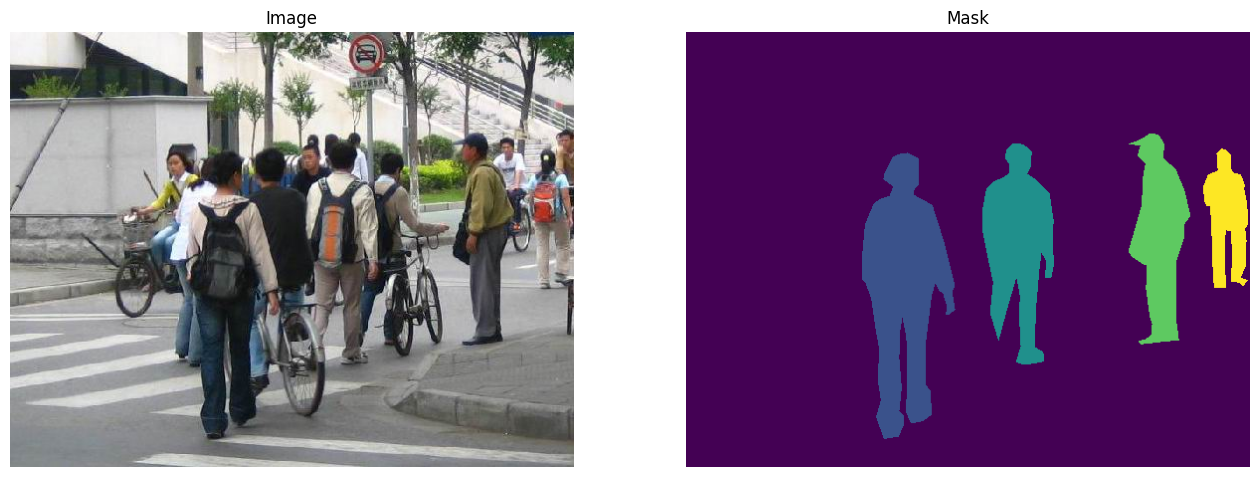

In [2]:
import matplotlib.pyplot as plt, os


from torchvision.io import read_image
import torch, numpy as np
#Observe image and mask

image= read_image('data/PennFudanPed/PNGImages/FudanPed00046.png')
mask = read_image('data/PennFudanPed/PedMasks/FudanPed00046_mask.png')



plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title('Image')
_=plt.imshow(image.permute(1, 2, 0))
_ = plt.axis(False)
plt.subplot(122)
plt.title('Mask')
_=plt.imshow(mask.permute(1, 2, 0))
_ =plt.axis(False)

print(torch.unique(mask))

In [3]:
import os, torch
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F


class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root 
        self.transforms=transforms 
        # load all image files, sorting them to ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root, 'PNGImages'))))
        self.masks = [f for f in sorted(os.listdir(os.path.join(root, 'PedMasks'))) if os.path.isfile(os.path.join(root, 'PedMasks', f))]
    
    def __getitem__(self, idx):
        #load images and masks
        img_path =os.path.join(self.root, 'PNGImages', self.imgs[idx])
        mask_path=os.path.join(self.root, 'PedMasks', self.masks[idx])
        img = read_image(img_path)
        mask = read_image(mask_path)
        #Instances are encoded as different colors
        obj_ids = torch.unique(mask)
        # first id is the background, so we remove it
        obj_ids =obj_ids[1:]
        num_objs = len(obj_ids)

        #split the color-encoded mask into a set of binary masks
        masks=(mask==obj_ids[:, None, None]).to(dtype = torch.uint8)

        #get bounding box coordinatess for each mask
        boxes = masks_to_boxes(masks)

        # there is only one class 
        labels = torch.ones((num_objs,), dtype =torch.int64)

        
        image_id = idx
        width = boxes[:, 3] - boxes[:, 1]
        height= boxes[:, 2] - boxes[:, 0]
        area =  width * height 
        

        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # wrap sample and targets into torchvision tv_tensors
        img = tv_tensors.Image(img)

        target = {}
        target['boxes'] = tv_tensors.BoundingBoxes(boxes, format='XYXY', canvas_size=F.get_size(img))
        target['masks'] = tv_tensors.Mask(masks)
        target['labels'] = labels
        target['image_id'] = image_id
        target['area'] = area
        target['iscrowd'] = iscrowd
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.imgs)
        
        
        

In [4]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model  = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

# replace the classifier
num_classes = 2    # 1class person + background
#get number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features

#replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)



In [5]:
# from torchvision.models.detection import FasterRCNN
# from torchvision.models.detection.rpn import AnchorGenerator

# backbone = torchvision.models.mobilenet_v2(weights='DEFAULT').features

# # ``FasterRCNN`` needs to know the number of
# # output channels in a backbone. For mobilenet_v2, it's 1280
# # so we need to add it here
# backbone.out_channels = 1280
# # let's make the RPN generate 5 x 3 anchors per spatial
# # location, with 5 different sizes and 3 different aspect
# # ratios. We have a Tuple[Tuple[int]] because each feature
# # map could potentially have different sizes and
# # aspect ratios

# anchor_generator = AnchorGenerator(
#     sizes = ((32, 64, 128, 256, 512),),
#     aspect_ratios = ((0.5, 1.0, 2.0),)
# )

# # let's define what are the feature maps that we will
# # use to perform the region of interest cropping, as well as
# # the size of the crop after rescaling.
# # if backbone returns a Tensor, featmap_names is expected to
# # be [0]. More generally, the backbone should return an
# # ``OrderedDict[Tensor]``, and in ``featmap_names`` you can choose which
# # feature maps to use.

# roi_pooler = torchvision.ops.MultiScaleRoIAlign(
#     featmap_names =['0'],
#     output_size=7,
#     sampling_ratio=2
# )

# model = FasterRCNN(
#     backbone,
#     num_classes=2,
#     rpn_anchor_generator = anchor_generator,
#     box_roi_pool = roi_pooler
# )

In [6]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def get_model_instance_segmentation(num_classes):

    #load and instance segmentation model pre-trained on Coco

    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights='DEFAULT')

    # get the number of output features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    #replace = the pre_trained head with a  new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    #get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    #and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )
    return model

In [7]:
from torchvision.transforms import v2 as T

def get_transform(train=False):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)
print(get_transform())

Compose(
      ToDtype(scale=True)
      ToPureTensor()
)


In [8]:
import utils 
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
dataset = PennFudanDataset('data/PennFudanPed', get_transform(train=True))
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=utils.collate_fn
)
# For Training
images, targets = next(iter(data_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets)
print(output)

# For inference
model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions  = model(x) # Returns predictions
print(predictions[0])

{'loss_classifier': tensor(0.2021, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0769, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0229, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0073, grad_fn=<DivBackward0>)}
{'boxes': tensor([], size=(0, 4), grad_fn=<StackBackward0>), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([], grad_fn=<IndexBackward0>)}


In [ ]:
from engine import train_one_epoch, evaluate
from torch.utils.data import DataLoader



device=torch.device('cuda' if torch.cuda.is_available() else torch.device('cpu'))
print(device)
num_classes=2
dataset = PennFudanDataset('data/PennFudanPed', get_transform(train = 'True'))
dataset_test = PennFudanDataset('data/PennFudanPed', get_transform(train='True'))

#split the dataset into train and test set
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

train_dl = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    collate_fn = utils.collate_fn
)

data_loader_test = DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn =utils.collate_fn
)

model = get_model_instance_segmentation(num_classes)

model.to(device)

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr =0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

num_epochs =10

for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    lr_scheduler.step()
    evaluate(model, data_loader_test, device)
torch.save(model.state_dict(), 'maskrcnn_pennfudan.pth')
print('training finished')

cuda
Epoch: [0]  [ 0/22]  eta: 0:00:07  lr: 0.000243  loss: 1.6752 (1.6752)  loss_classifier: 0.6410 (0.6410)  loss_box_reg: 0.2672 (0.2672)  loss_mask: 0.7530 (0.7530)  loss_objectness: 0.0100 (0.0100)  loss_rpn_box_reg: 0.0039 (0.0039)  time: 0.3583  data: 0.1200  max mem: 11965
Epoch: [0]  [10/22]  eta: 0:00:04  lr: 0.002621  loss: 1.1346 (1.1508)  loss_classifier: 0.2956 (0.3570)  loss_box_reg: 0.2945 (0.3237)  loss_mask: 0.4340 (0.4483)  loss_objectness: 0.0161 (0.0165)  loss_rpn_box_reg: 0.0049 (0.0053)  time: 0.3534  data: 0.1070  max mem: 11965
Epoch: [0]  [20/22]  eta: 0:00:00  lr: 0.005000  loss: 0.7035 (0.8875)  loss_classifier: 0.1721 (0.2381)  loss_box_reg: 0.2605 (0.2835)  loss_mask: 0.2433 (0.3479)  loss_objectness: 0.0145 (0.0129)  loss_rpn_box_reg: 0.0045 (0.0051)  time: 0.3666  data: 0.1078  max mem: 11965
Epoch: [0]  [21/22]  eta: 0:00:00  lr: 0.005000  loss: 0.6399 (0.8689)  loss_classifier: 0.1651 (0.2306)  loss_box_reg: 0.2568 (0.2820)  loss_mask: 0.2400 (0.3387) 

In [ ]:
import torchvision.transforms.functional as TF
from torchvision.io import read_image

model = get_model_instance_segmentation(num_classes=2)
model.load_state_dict(torch.load('maskrcnn_pennfudan.pth'))
model.to(device)



# Pick any image from the dataset
img_path = 'data/PennFudanPed/PNGImages/FudanPed00046.png'
img_tensor = read_image(img_path)

# Preprocess: convert to float [0,1]
img_float = TF.convert_image_dtype(img_tensor, torch.float)

model.eval()
with torch.no_grad():
    prediction = model([img_float.to(device)])[0]

print("Boxes:", prediction['boxes'].shape)
print("Scores:", prediction['scores'])
print("Masks:", prediction['masks'].shape)   # (N, 1, H, W) — probabilities

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

SCORE_THRESHOLD = 0.5

img_np = img_tensor.permute(1, 2, 0).numpy()   # H x W x C

boxes  = prediction['boxes'].cpu()
scores = prediction['scores'].cpu()
masks  = prediction['masks'].cpu().squeeze(1)  # N x H x W

# Filter by confidence
keep = scores > SCORE_THRESHOLD
boxes, scores, masks = boxes[keep], scores[keep], masks[keep]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Left: bounding boxes ---
axes[0].imshow(img_np)
axes[0].set_title(f'Boxes ({len(boxes)} detections)')
colors = plt.cm.tab10.colors
for i, (box, score) in enumerate(zip(boxes, scores)):
    x1, y1, x2, y2 = box.tolist()
    color = colors[i % len(colors)]
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor=color, facecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(x1, y1 - 4, f'{score:.2f}', color=color, fontsize=10,
                 fontweight='bold')
axes[0].axis('off')

# --- Right: instance masks overlaid ---
overlay = img_np.copy().astype(np.float32) / 255.0
for i, mask in enumerate(masks):
    color = np.array(colors[i % len(colors)][:3])
    binary = (mask.numpy() > 0.5)
    overlay[binary] = overlay[binary] * 0.4 + color * 0.6   # blend

axes[1].imshow(overlay)
axes[1].set_title('Instance Masks')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('inference_result.png', dpi=150)
plt.show()